In [1]:
import argparse
from os import path
import pandas as pd
import seaborn as sns

import mne
import numpy as np
from scipy.stats import permutation_test, false_discovery_control, norm
from scipy.signal import detrend
from mne_bids import BIDSPath, read_raw_bids
from mne_bids.dig import _read_dig_bids
from mne_bids.path import _find_matching_sidecar
from mne.time_frequency import read_tfrs
from ieeg.navigate import channel_outlier_marker
from ieeg.navigate import outliers_to_nan
from ieeg.calc.scaling import rescale
from ieeg.timefreq import gamma
from ieeg.timefreq.multitaper import spectrogram
from ieeg.timefreq.utils import crop_pad
from ieeg.viz.ensemble import plot2d_chanMap
from ieeg.io import raw_from_layout
from bids.layout import BIDSLayout
from pathlib import Path
from ieeg.navigate import trial_ieeg
from mne_bids import get_bids_path_from_fname
import re
import logging
import sys
from joblib import Parallel, delayed

%matplotlib inline

Qt5Agg backend not available, using default backend
Qt5Agg backend not available, using default backend


# Calculate spectrograms

In [2]:
def find_channel_outliers(data, threshold=3):
    data = detrend(data, axis=1)  # ensure detrending along time
    R2 = np.square(data)
    R2[R2 == 0] = 1e-9

    sig = np.std(R2, axis=1)
    m, s = norm.fit(sig)
    out1 = np.where(sig > (threshold*s + m))[0]
    mask = np.setdiff1d(np.arange(len(sig)), out1)
    m2, s2 = norm.fit(sig[mask])
    out2 = np.where(sig[mask] > (threshold*s2 + m2))[0]
    chan_outliers = np.sort(np.concatenate([out1, mask[out2]])) + 1
    chan_outliers = [str(chan) for chan in chan_outliers]
    return chan_outliers

def remove_bad_trials(data, threshold=10, method=1):
    """Removes bad trials based on a threshold detection.

    This function evaluates each trial for every channel and removes those
    considered "bad" based on the specified thresholding method.

    Args:
        data (np.ndarray): 
            Array of shape (electrodes, trials, samples) representing the recorded data.
        threshold (float, optional): 
            Threshold for identifying noisy trials. Defaults to 10.
        method (int, optional): 
            Method for thresholding:
            
            - 1: Uses an absolute amplitude threshold based on mean and standard deviation.
            - 2: Uses a differential threshold on the first temporal derivative.
            
            Defaults to 1.

    Returns:
        tuple[np.ndarray, np.ndarray]: 
            - **NumTrials** (`np.ndarray`): Array of shape (electrodes,) containing 
              the number of good trials for each channel.
            - **goodtrials** (`np.ndarray`): Boolean array of shape (electrodes, trials)
              indicating which trials are considered good.

    Raises:
        ValueError: If `method` is not 1 or 2.
    """
    n_trials, n_channels, _ = data.shape
    NumTrials = np.zeros(n_channels, dtype=int)
    goodtrials = np.zeros((n_channels, n_trials), dtype=bool)

    for iCh in range(n_channels):
        tmp = data[:, iCh, :]  # shape: (trials, samples)

        if method == 1:
            th = threshold * np.std(np.abs(tmp)) + np.mean(np.abs(tmp))
            e = np.max(np.abs(tmp), axis=1)
            mask = (e < th) & (e != 0)
        elif method == 2:
            difftmp = np.diff(tmp, axis=1)
            e = np.max(difftmp, axis=1)
            mask = e < threshold
        else:
            raise ValueError("method must be 1 or 2")

        NumTrials[iCh] = np.sum(mask)
        goodtrials[iCh, :] = mask

    return NumTrials, goodtrials

In [ ]:
# Simple logging: everything INFO and above to stdout
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    stream=sys.stdout,
)
logger = logging.getLogger(__name__)

def preproc(
    bids_layout: BIDSLayout,
    subject: str,
    tmin: float,
    tmax: float,
    fs: int,
    ref: str,
    freq: np.ndarray = np.arange(10, 200., 6.),
    **kwargs
):
    # Load data
    raw = raw_from_layout(
        bids_layout,
        subject=subject,
        extension='.edf',
        desc=None,
        **kwargs
    )
    raw.load_data()
    raw._data *= 1e6  # convert to uV
    nChans = raw.info['nchan']

    events, event_id = mne.events_from_annotations(raw)
    baseline_events = [e for e in event_id.keys() if 'stimulus' in e]
    resp_events = [e for e in event_id.keys() if 'response' in e]

    resp_epochs = trial_ieeg(
        raw,
        event=resp_events,
        times=[-3, 3],
        preload=True,
    )
    # channel outlier removal based on detrended concatenated data
    data_chan_time = resp_epochs.get_data().transpose(1,0,2).reshape(resp_epochs.info['nchan'], -1)
    bad_channels_detrend = find_channel_outliers(data_chan_time)
    print(f"IEEG BAD CHANNELS DETREND PHONEME EPOCHS: {bad_channels_detrend}")
    bad_channels_tot = list(set(raw.info['bads'] + bad_channels_detrend))

    # update bads in raw objects with new outliers
    raw.info['bads'] = bad_channels_tot
    # raw_phon.info['bads'] = bad_channels_tot
    # raw.drop_channels(bad_channels_tot)

    # remove Trigger channel we have any
    raw.drop_channels(['Trigger']) if 'Trigger' in raw.ch_names else None
    ch_type = raw.get_channel_types(only_data_chs=True)[0]
    print(f"Available channel types: {ch_type}")

    # Notch filter power line noise
    powerline_freq = raw.info.get("line_freq")
    if powerline_freq is None:
        powerline_freq = 60
    freqs = [powerline_freq * m for m in range(1, 4)]
    raw.notch_filter(freqs=freqs, notch_widths=2, n_jobs=-1)

    # Re-reference data
    logger.info(f'Setting re-reference scheme: {ref}')

    raw = raw.set_eeg_reference(ref_channels="average", ch_type=ch_type)


    base_epochs = trial_ieeg(
        raw,
        event=baseline_events,
        times=[-1, 0.5],
        preload=True,
    )
    # recreate raw after filtering and CAR
    resp_epochs = trial_ieeg(
        raw,
        event=resp_events,
        times=[-3, 3],
        preload=True,
    )

    ##### Bad Trial Removal #####
    tr_remove_data_prod = resp_epochs._data
    _, goodtrials_production = remove_bad_trials(tr_remove_data_prod, threshold=10, method=1)
    nChans = tr_remove_data_prod.shape[1]
    goodtrials_production_common = np.sum(goodtrials_production, axis=0) >= (0.8 * nChans)
    resp_epochs = resp_epochs[goodtrials_production_common]
    base_epochs = base_epochs[goodtrials_production_common]
    ##########

    spectra = spectrogram(resp_epochs, freq, base_epochs, verbose=10, n_cycles=freq/2, n_jobs=-1, picks=resp_epochs.ch_names)

    # n_cycles = freq * 0.05  # 50 ms window
    # n_cycles = np.clip(n_cycles, 3, 15)
    # spectra = spectrogram(resp_epochs, freq, base_epochs, verbose=10, n_cycles=n_cycles, n_jobs=-1, picks=resp_epochs.ch_names)
    crop_pad(spectra, "0.5s")

    return spectra


def remove_arpabet_stress(phoneme: str) -> str:
    """Remove stress markers from ARPAbet phonemes.

    E.g., 'AH0' -> 'AH', 'IY1' -> 'IY'
    """
    return re.sub(r'\d', '', phoneme)


def swap_kv_dict(d):
    return dict((v, k) for k, v in d.items())

def main(bids_root: str, subject: str, tmin: float = -1.0,
         tmax: float = 1.5, fs: int = 200, **kwargs):

    bids_layout = BIDSLayout(
        root=bids_root,
        derivatives=True,
    )
    spectra = preproc(
        bids_layout=bids_layout,
        subject=subject,
        tmin=tmin,
        tmax=tmax,
        fs=fs,
        **kwargs
    )

    return spectra


In [8]:
pt = 'S82'
freqs = np.arange(1, 200., 6.)
# freqs = np.concatenate((np.arange(10, 200, 6), np.logspace(np.log10(200), np.log10(1000), 50)))
# freqs = np.logspace(np.log10(300), np.log10(1000), 30)
# freqs = np.logspace(np.log10(300), np.log10(500), 15)
# freqs = np.logspace(np.log10(500), np.log10(750), 15)
# freqs = np.logspace(np.log10(750), np.log10(1000), 15)

spectra = main(bids_root='/hpc/home/zms14/cworkspace/BIDS_1.0_Lexical_µECoG/BIDS', subject=pt, tmin=-1, tmax=1.5, fs=200, ref='CAR', freq=freqs)
# spectra.save(f'spectra_300-1000_{pt}.h5', overwrite=True)

Extracting EDF parameters from /hpc/home/zms14/cworkspace/BIDS_1.0_Lexical_µECoG/BIDS/sub-S82/ieeg/sub-S82_task-lexical_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /hpc/home/zms14/cworkspace/BIDS_1.0_Lexical_µECoG/BIDS/sub-S82/ieeg/sub-S82_task-lexical_events.tsv.
The event "response" refers to multiple event values.Creating hierarchical event names.
    Renaming event: response -> response/magic
    Renaming event: response -> response/pedal
    Renaming event: response -> response/tacin
    Renaming event: response -> response/comet
    Renaming event: response -> response/savin
    Renaming event: response -> response/nasal
    Renaming event: response -> response/topic
    Renaming event: response -> response/havel
    Renaming event: response -> response/roman
    Renaming event: response -> response/linen
    Renaming event: response -> response/woman
    Renaming event: response -> response/viral
    Renaming

: 

# Plotting

### Utils

In [2]:
from matplotlib.colors import LinearSegmentedColormap

parula_data = [[0.2422, 0.1504, 0.6603],
[0.2444, 0.1534, 0.6728],
[0.2464, 0.1569, 0.6847],
[0.2484, 0.1607, 0.6961],
[0.2503, 0.1648, 0.7071],
[0.2522, 0.1689, 0.7179],
[0.254, 0.1732, 0.7286],
[0.2558, 0.1773, 0.7393],
[0.2576, 0.1814, 0.7501],
[0.2594, 0.1854, 0.761],
[0.2611, 0.1893, 0.7719],
[0.2628, 0.1932, 0.7828],
[0.2645, 0.1972, 0.7937],
[0.2661, 0.2011, 0.8043],
[0.2676, 0.2052, 0.8148],
[0.2691, 0.2094, 0.8249],
[0.2704, 0.2138, 0.8346],
[0.2717, 0.2184, 0.8439],
[0.2729, 0.2231, 0.8528],
[0.274, 0.228, 0.8612],
[0.2749, 0.233, 0.8692],
[0.2758, 0.2382, 0.8767],
[0.2766, 0.2435, 0.884],
[0.2774, 0.2489, 0.8908],
[0.2781, 0.2543, 0.8973],
[0.2788, 0.2598, 0.9035],
[0.2794, 0.2653, 0.9094],
[0.2798, 0.2708, 0.915],
[0.2802, 0.2764, 0.9204],
[0.2806, 0.2819, 0.9255],
[0.2809, 0.2875, 0.9305],
[0.2811, 0.293, 0.9352],
[0.2813, 0.2985, 0.9397],
[0.2814, 0.304, 0.9441],
[0.2814, 0.3095, 0.9483],
[0.2813, 0.315, 0.9524],
[0.2811, 0.3204, 0.9563],
[0.2809, 0.3259, 0.96],
[0.2807, 0.3313, 0.9636],
[0.2803, 0.3367, 0.967],
[0.2798, 0.3421, 0.9702],
[0.2791, 0.3475, 0.9733],
[0.2784, 0.3529, 0.9763],
[0.2776, 0.3583, 0.9791],
[0.2766, 0.3638, 0.9817],
[0.2754, 0.3693, 0.984],
[0.2741, 0.3748, 0.9862],
[0.2726, 0.3804, 0.9881],
[0.271, 0.386, 0.9898],
[0.2691, 0.3916, 0.9912],
[0.267, 0.3973, 0.9924],
[0.2647, 0.403, 0.9935],
[0.2621, 0.4088, 0.9946],
[0.2591, 0.4145, 0.9955],
[0.2556, 0.4203, 0.9965],
[0.2517, 0.4261, 0.9974],
[0.2473, 0.4319, 0.9983],
[0.2424, 0.4378, 0.9991],
[0.2369, 0.4437, 0.9996],
[0.2311, 0.4497, 0.9995],
[0.225, 0.4559, 0.9985],
[0.2189, 0.462, 0.9968],
[0.2128, 0.4682, 0.9948],
[0.2066, 0.4743, 0.9926],
[0.2006, 0.4803, 0.9906],
[0.195, 0.4861, 0.9887],
[0.1903, 0.4919, 0.9867],
[0.1869, 0.4975, 0.9844],
[0.1847, 0.503, 0.9819],
[0.1831, 0.5084, 0.9793],
[0.1818, 0.5138, 0.9766],
[0.1806, 0.5191, 0.9738],
[0.1795, 0.5244, 0.9709],
[0.1785, 0.5296, 0.9677],
[0.1778, 0.5349, 0.9641],
[0.1773, 0.5401, 0.9602],
[0.1768, 0.5452, 0.956],
[0.1764, 0.5504, 0.9516],
[0.1755, 0.5554, 0.9473],
[0.174, 0.5605, 0.9432],
[0.1716, 0.5655, 0.9393],
[0.1686, 0.5705, 0.9357],
[0.1649, 0.5755, 0.9323],
[0.161, 0.5805, 0.9289],
[0.1573, 0.5854, 0.9254],
[0.154, 0.5902, 0.9218],
[0.1513, 0.595, 0.9182],
[0.1492, 0.5997, 0.9147],
[0.1475, 0.6043, 0.9113],
[0.1461, 0.6089, 0.908],
[0.1446, 0.6135, 0.905],
[0.1429, 0.618, 0.9022],
[0.1408, 0.6226, 0.8998],
[0.1383, 0.6272, 0.8975],
[0.1354, 0.6317, 0.8953],
[0.1321, 0.6363, 0.8932],
[0.1288, 0.6408, 0.891],
[0.1253, 0.6453, 0.8887],
[0.1219, 0.6497, 0.8862],
[0.1185, 0.6541, 0.8834],
[0.1152, 0.6584, 0.8804],
[0.1119, 0.6627, 0.877],
[0.1085, 0.6669, 0.8734],
[0.1048, 0.671, 0.8695],
[0.1009, 0.675, 0.8653],
[0.0964, 0.6789, 0.8609],
[0.0914, 0.6828, 0.8562],
[0.0855, 0.6865, 0.8513],
[0.0789, 0.6902, 0.8462],
[0.0713, 0.6938, 0.8409],
[0.0628, 0.6972, 0.8355],
[0.0535, 0.7006, 0.8299],
[0.0433, 0.7039, 0.8242],
[0.0328, 0.7071, 0.8183],
[0.0234, 0.7103, 0.8124],
[0.0155, 0.7133, 0.8064],
[0.0091, 0.7163, 0.8003],
[0.0046, 0.7192, 0.7941],
[0.0019, 0.722, 0.7878],
[0.0009, 0.7248, 0.7815],
[0.0018, 0.7275, 0.7752],
[0.0046, 0.7301, 0.7688],
[0.0094, 0.7327, 0.7623],
[0.0162, 0.7352, 0.7558],
[0.0253, 0.7376, 0.7492],
[0.0369, 0.74, 0.7426],
[0.0504, 0.7423, 0.7359],
[0.0638, 0.7446, 0.7292],
[0.077, 0.7468, 0.7224],
[0.0899, 0.7489, 0.7156],
[0.1023, 0.751, 0.7088],
[0.1141, 0.7531, 0.7019],
[0.1252, 0.7552, 0.695],
[0.1354, 0.7572, 0.6881],
[0.1448, 0.7593, 0.6812],
[0.1532, 0.7614, 0.6741],
[0.1609, 0.7635, 0.6671],
[0.1678, 0.7656, 0.6599],
[0.1741, 0.7678, 0.6527],
[0.1799, 0.7699, 0.6454],
[0.1853, 0.7721, 0.6379],
[0.1905, 0.7743, 0.6303],
[0.1954, 0.7765, 0.6225],
[0.2003, 0.7787, 0.6146],
[0.2061, 0.7808, 0.6065],
[0.2118, 0.7828, 0.5983],
[0.2178, 0.7849, 0.5899],
[0.2244, 0.7869, 0.5813],
[0.2318, 0.7887, 0.5725],
[0.2401, 0.7905, 0.5636],
[0.2491, 0.7922, 0.5546],
[0.2589, 0.7937, 0.5454],
[0.2695, 0.7951, 0.536],
[0.2809, 0.7964, 0.5266],
[0.2929, 0.7975, 0.517],
[0.3052, 0.7985, 0.5074],
[0.3176, 0.7994, 0.4975],
[0.3301, 0.8002, 0.4876],
[0.3424, 0.8009, 0.4774],
[0.3548, 0.8016, 0.4669],
[0.3671, 0.8021, 0.4563],
[0.3795, 0.8026, 0.4454],
[0.3921, 0.8029, 0.4344],
[0.405, 0.8031, 0.4233],
[0.4184, 0.803, 0.4122],
[0.4322, 0.8028, 0.4013],
[0.4463, 0.8024, 0.3904],
[0.4608, 0.8018, 0.3797],
[0.4753, 0.8011, 0.3691],
[0.4899, 0.8002, 0.3586],
[0.5044, 0.7993, 0.348],
[0.5187, 0.7982, 0.3374],
[0.5329, 0.797, 0.3267],
[0.547, 0.7957, 0.3159],
[0.5609, 0.7943, 0.305],
[0.5748, 0.7929, 0.2941],
[0.5886, 0.7913, 0.2833],
[0.6024, 0.7896, 0.2726],
[0.6161, 0.7878, 0.2622],
[0.6297, 0.7859, 0.2521],
[0.6433, 0.7839, 0.2423],
[0.6567, 0.7818, 0.2329],
[0.6701, 0.7796, 0.2239],
[0.6833, 0.7773, 0.2155],
[0.6963, 0.775, 0.2075],
[0.7091, 0.7727, 0.1998],
[0.7218, 0.7703, 0.1924],
[0.7344, 0.7679, 0.1852],
[0.7468, 0.7654, 0.1782],
[0.759, 0.7629, 0.1717],
[0.771, 0.7604, 0.1658],
[0.7829, 0.7579, 0.1608],
[0.7945, 0.7554, 0.157],
[0.806, 0.7529, 0.1546],
[0.8172, 0.7505, 0.1535],
[0.8281, 0.7481, 0.1536],
[0.8389, 0.7457, 0.1546],
[0.8495, 0.7435, 0.1564],
[0.86, 0.7413, 0.1587],
[0.8703, 0.7392, 0.1615],
[0.8804, 0.7372, 0.165],
[0.8903, 0.7353, 0.1695],
[0.9, 0.7336, 0.1749],
[0.9093, 0.7321, 0.1815],
[0.9184, 0.7308, 0.189],
[0.9272, 0.7298, 0.1973],
[0.9357, 0.729, 0.2061],
[0.944, 0.7285, 0.2151],
[0.9523, 0.7284, 0.2237],
[0.9606, 0.7285, 0.2312],
[0.9689, 0.7292, 0.2373],
[0.977, 0.7304, 0.2418],
[0.9842, 0.733, 0.2446],
[0.99, 0.7365, 0.2429],
[0.9946, 0.7407, 0.2394],
[0.9966, 0.7458, 0.2351],
[0.9971, 0.7513, 0.2309],
[0.9972, 0.7569, 0.2267],
[0.9971, 0.7626, 0.2224],
[0.9969, 0.7683, 0.2181],
[0.9966, 0.774, 0.2138],
[0.9962, 0.7798, 0.2095],
[0.9957, 0.7856, 0.2053],
[0.9949, 0.7915, 0.2012],
[0.9938, 0.7974, 0.1974],
[0.9923, 0.8034, 0.1939],
[0.9906, 0.8095, 0.1906],
[0.9885, 0.8156, 0.1875],
[0.9861, 0.8218, 0.1846],
[0.9835, 0.828, 0.1817],
[0.9807, 0.8342, 0.1787],
[0.9778, 0.8404, 0.1757],
[0.9748, 0.8467, 0.1726],
[0.972, 0.8529, 0.1695],
[0.9694, 0.8591, 0.1665],
[0.9671, 0.8654, 0.1636],
[0.9651, 0.8716, 0.1608],
[0.9634, 0.8778, 0.1582],
[0.9619, 0.884, 0.1557],
[0.9608, 0.8902, 0.1532],
[0.9601, 0.8963, 0.1507],
[0.9596, 0.9023, 0.148],
[0.9595, 0.9084, 0.145],
[0.9597, 0.9143, 0.1418],
[0.9601, 0.9203, 0.1382],
[0.9608, 0.9262, 0.1344],
[0.9618, 0.932, 0.1304],
[0.9629, 0.9379, 0.1261],
[0.9642, 0.9437, 0.1216],
[0.9657, 0.9494, 0.1168],
[0.9674, 0.9552, 0.1116],
[0.9692, 0.9609, 0.1061],
[0.9711, 0.9667, 0.1001],
[0.973, 0.9724, 0.0938],
[0.9749, 0.9782, 0.0872],
[0.9769, 0.9839, 0.0805]]

parula_map = LinearSegmentedColormap.from_list('parula', parula_data)

### Main

In [9]:
# spectra = read_tfrs('spectra_hf.h5')
spectra = read_tfrs('spectra_300-1000_S73.h5')
# spectra = read_tfrs('spectra_300-500.h5')
# spectra = read_tfrs('spectra_500-750.h5')
# spectra = read_tfrs('spectra_broad_S81.h5')
# spectra = read_tfrs('spectra_HG_S81.h5')
# spectra = read_tfrs('spectra_HG_S73.h5')
spectra.info

Reading /cwork/zms14/BIDS_1.0_Lexical_µECoG/BIDS/code/visualization/spectra_300-1000_S73.h5 ...


/tmp/ipykernel_2572320/3747035212.py:2: RuntimeWarning: This filename (/cwork/zms14/BIDS_1.0_Lexical_µECoG/BIDS/code/visualization/spectra_300-1000_S73.h5) does not conform to MNE naming conventions. All tfr files should end with -tfr.h5, -tfr.hdf5, _tfr.h5 or _tfr.hdf5
  spectra = read_tfrs('spectra_300-1000_S73.h5')


<Info | 11 non-empty values
 bads: 11 items (230, 252, 244, 84, 202, 233, 177, 76, 176, 34, 224)
 ch_names: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, ...
 chs: 256 ECoG
 custom_ref_applied: True
 dig: 256 items (256 EEG)
 highpass: 0.0 Hz
 lowpass: 1000.0 Hz
 meas_date: 1985-01-01 00:00:00 UTC
 nchan: 256
 projs: []
 sfreq: 2000.0 Hz
 subject_info: <subject_info | hand: 0, his_id: sub-S73, sex: 0>
>

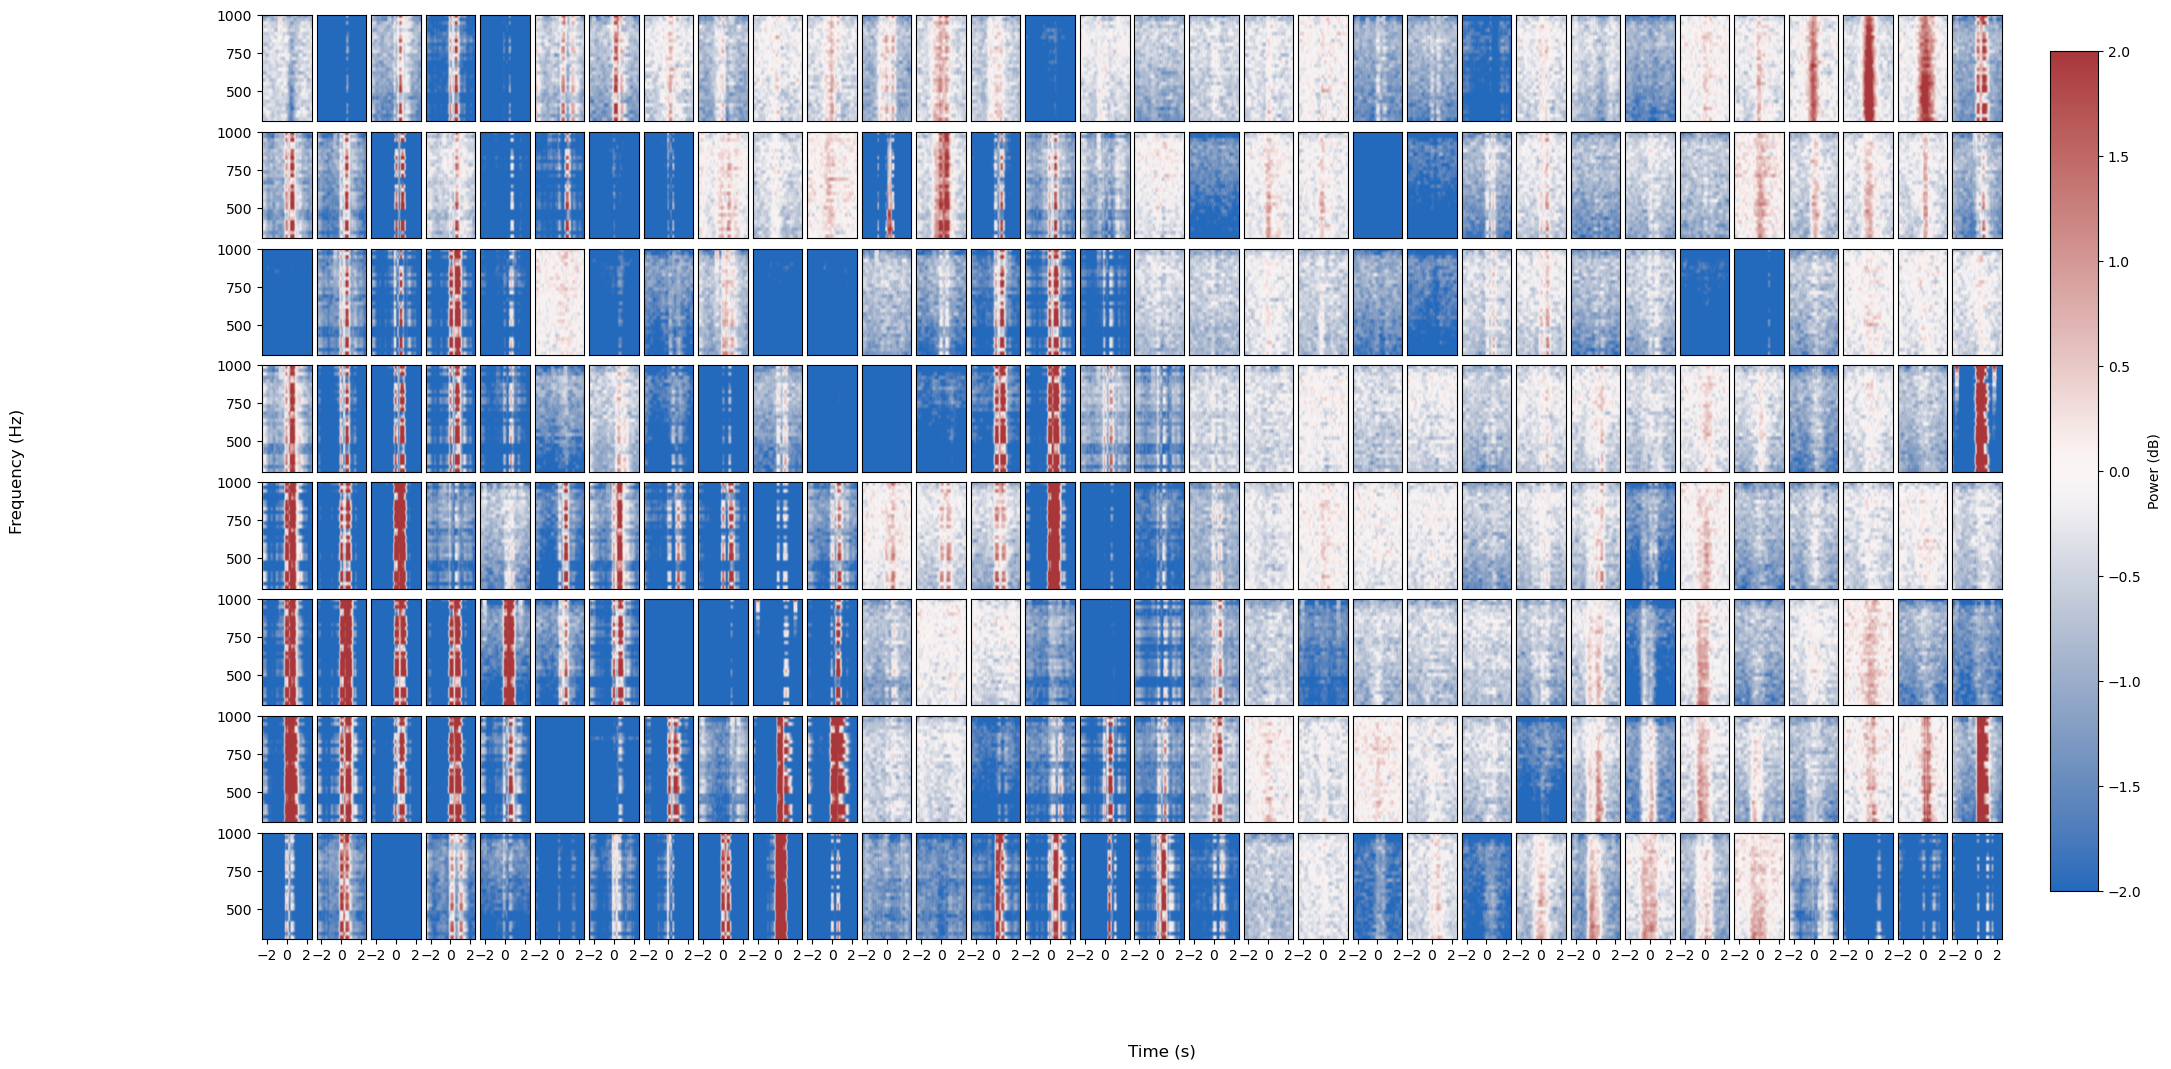

In [10]:
chan_map_grid256 = np.array([
    [ np.nan,  80.,  78., 127., 115., 125.,  72.,  81.,  68.,  77.,  69.,
      82., 186., 184., 182., 191., 179., 189., 136., 145., 132., 177.,
    181.,  np.nan],
    [ np.nan,  52.,  29.,  27.,   2.,  59.,  36.,  34.,  51.,  74.,  67.,
      71., 188., 163., 185., 209., 221., 219., 194., 251., 228., 226.,
    198.,  np.nan],
    [ np.nan,  45.,  42.,  58.,  44.,  47.,  19.,  38.,  57., 121.,  65.,
      73., 190., 160., 138., 202., 217., 232., 207., 215., 210., 212.,
    214.,  np.nan],
    [ np.nan,  26.,  35.,  32.,   1.,  33.,  60.,  54.,  10., 117.,  89.,
      94., 192., 166., 144., 249., 205., 199., 229., 224., 193., 195.,
    233.,  np.nan],
    [ np.nan, 118.,  15.,  23.,  18.,  28.,  56.,  13.,  17., 113.,  83.,
      97., 165., 168., 142., 243., 246., 197., 231., 250., 236., 239.,
    141.,  np.nan],
    [ np.nan,  98., 116., 112., 123.,   3.,  64.,  25.,  14.,  49.,  87.,
      84., 170., 172., 206., 241., 230., 222., 227., 130., 159., 134.,
    157.,  np.nan],
    [ np.nan, 120.,  99.,  96., 100.,   9.,  41.,   6.,  61., 119.,  75.,
      86., 173., 178., 140., 200., 244., 218., 254., 155., 129., 131.,
    133.,  np.nan],
    [ np.nan, 103., 110., 111., 114.,  24.,  30.,  21.,  48.,  16.,  91.,
      79., 175., 164., 245., 223., 238., 256., 235., 139., 143., 149.,
    156.,  np.nan],
    [ np.nan, 109., 107., 105., 108.,   5.,  62.,  11.,  63.,  12.,  93.,
      85., 174., 162., 247., 196., 242., 201., 248., 151., 154., 152.,
    150.,  np.nan],
    [ np.nan, 128., 101., 106., 104.,   7.,  37.,  50.,   8.,  55.,  70.,
      92., 167., 180., 204., 253., 203., 225., 252., 147., 148., 161.,
    158.,  np.nan],
    [ np.nan, 126., 124., 122., 102.,  22.,  39.,  46.,  31.,  53.,  66.,
      90., 169., 187., 208., 240., 213., 220., 237., 153., 146., 135.,
    137.,  np.nan],
    [ np.nan,  np.nan,  np.nan,  np.nan,  np.nan,  20.,  43.,  40.,   4.,  76.,  95.,
      88., 171., 176., 183., 255., 211., 216., 234.,  np.nan,  np.nan,  np.nan,
      np.nan,  np.nan]
])
chan_map_strip256 = np.flipud(np.array([
    [151,	147,	152,	155,	159,	148,	150,	154,	156,	158,	144,	145,	149,	153,	157,	141,	143,	146,	142,	139,	137,	138,	135,	136,	140,	238,	237,	236,	234,	233,	235,	232],
    [223,	219,	224,	229,	225,	227,	226,	228,	217,	230,	222,	231,	220,	216,	218,	221,	215,	213,	214,	212,	211,	210,	209,	240,	239,	241,	206,	208,	207,	245,	242,	243],
    [248,	251,	249,	201,	198,	203,	199,	200, 196,	247,	252,	244,	250,	246,	253,	202,	194,	205,	197,	204,	195,	128,	254,	255,	192,	193,	191,	131,	129,	130,	189,	190],
    [173,	177,	176,	180,	178,	182,	160,	181,	164,	184,	168,	183,	174, 179,	175,	185,	163,	186,	165, 18, 167,	132,	169,	133,	171,	134,	161,	188,	162,	166,	170,	172],
    [78,	82,	75,	79,	73,	77,	74,	96,	71,	91,	72,	87,	76,	81,	70,	80,	69, 92,	68,	90,	123,	88,	122,	86, 121,	84,	67,	94,	93,	89,	85,	83],
    [4,	7,	54,	6,	52,	57,	55,	56,	8,	59,	11,	3,	9,	5,	53,	2,	50,	61,	51,	58,	60,	127,	1,	0,	63,	62,	64,	124,	126,	125,	66,	65],
    [36,	31,	26,	32,	28,	30,	27,	29,	25,	38,	24,	33,	35,	39,	37,	34,	40,	42,	41,	43,	44,	45,	46,	15,	16,	14,	49,	47, 48,	10,	13,	12],
    [108,	103,	104,	100,	95,	107,	105,	101,	99,	97,	111,	110,	106,	102,	98,	114,	112,	109,	113,	116,	118,	117,	120,	119,	115,	17,	18,	19,	21,	22,	20,	23],
]))
# fig = plot2d_chanMap(spectra, chan_map_grid256, figsize=(24, 12), vmin=-4, vmax=4, cmap=sns.color_palette("vlag", as_cmap=True))
fig = plot2d_chanMap(spectra, chan_map_strip256, figsize=(24, 12), vmin=-2, vmax=2, cmap=sns.color_palette("vlag", as_cmap=True))
# fig.savefig()